In [12]:
from envmap import EnvironmentMap, rotation_matrix
from tools3d import spharm
import matplotlib.pyplot as plt
import numpy as np
import tqdm
from scipy.spatial.transform import Rotation as R

In [ ]:

# e = EnvironmentMap('/home/mint/Dev/DiFaReli/difareli-faster/eval_request/Sumit/difareli_test/kiara_2_sunrise_16k.exr0001.exr', 'latlong')
e = EnvironmentMap('/home/mint/Dev/DiFaReli/difareli-faster/eval_request/Sumit/difareli_test/kiara_2_sunrise_16k.exr0001.png', 'latlong')

sh = spharm.SphericalHarmonic(e, max_l=100)
reconstruction = sh.reconstruct(height=256, max_l=100)
plt.imshow(np.array(reconstruction))
plt.show()

sh = spharm.SphericalHarmonic(e, max_l=2)
reconstruction = sh.reconstruct(height=256, max_l=2)
plt.imshow(np.array(reconstruction))
plt.show()

dcm = rotation_matrix(azimuth=2*np.pi,
                      elevation=0,
                      roll=0)

sh = spharm.SphericalHarmonic(e.rotate(dcm), max_l=100)
reconstruction = sh.reconstruct(height=256, max_l=100)

# rotate environment map 1 degree around azimuth and save the result to video
def rotate_env(axis, n_frames, fn, max_l=2):
    rot_recon = []
    rot_e = []
    for i in tqdm.tqdm(np.linspace(0, 360, n_frames)):
        rot_deg = i*np.pi/180
        dcm = rotation_matrix(azimuth=rot_deg if axis == 'azimuth' else 0,
                            elevation=rot_deg if axis == 'elevation' else 0,
                            roll=rot_deg if axis == 'roll' else 0)
        sh = spharm.SphericalHarmonic(e.copy().rotate(dcm), max_l=max_l)
        e_rot = e.copy().rotate(dcm)
        reconstruction = sh.reconstruct(height=256, max_l=max_l)
        rot_e.append(e_rot)
        rot_recon.append(np.array(reconstruction))
        
    rot_recon = np.stack(rot_recon, axis=0)
    import torchvision.io as io
    import torch as th
    io.write_video(f'{fn}.mp4', (th.tensor(rot)/rot.max()) * 255, 30)
    
rotate_env('azimuth', 60, 'azimuth_l2', max_l=2)
rotate_env('elevation', 60, 'elevation_l2', max_l=2)
rotate_env('roll', 60, 'roll_l2', max_l=2)
rotate_env('azimuth', 60, 'azimuth_l100', max_l=100)
rotate_env('elevation', 60, 'elevation_l100', max_l=100)
rotate_env('roll', 60, 'roll_l100', max_l=100)

In [ ]:
def rotate_env(axis, n_frames, fn, max_l=2):
    rot = []
    shL = []
    for i in tqdm.tqdm(np.linspace(0, 360, n_frames)):
        rot_deg = i*np.pi/180
        dcm = rotation_matrix(azimuth=rot_deg if axis == 'azimuth' else 0,
                            elevation=rot_deg if axis == 'elevation' else 0,
                            roll=rot_deg if axis == 'roll' else 0)
        sh = spharm.SphericalHarmonic(e.copy().rotate(dcm), max_l=max_l)
        reconstruction = sh.reconstruct(height=64, max_l=max_l)
        rot.append(np.array(reconstruction))
        shL.append(sh)
    rot = np.stack(rot, axis=0)
    return rot, shL

e = EnvironmentMap('/home/mint/Dev/DiFaReli/difareli-faster/eval_request/Sumit/difareli_test/kiara_2_sunrise_16k.exr0001.png', 'latlong')
# e = EnvironmentMap('/home/mint/Dev/DiFaReli/difareli-faster/eval_request/Sumit/difareli_test/kiara_2_sunrise_16k.exr0001.exr', 'latlong')
rot, sh = rotate_env('roll', 20, 'roll_l2', max_l=2)


In [ ]:
print(rot.shape)
import torchvision.io as io
import torch as th
rotg = np.clip(rot, 0, None)  # Ensure no negative values
rotg /= rotg.max()  # Normalize to [0, 1] for visualization
io.write_video(f'gg.mp4', (th.tensor(rotg))[..., 1:4] * 255, 30)

In [ ]:
e = EnvironmentMap('/home/mint/Dev/DiFaReli/difareli-faster/eval_request/Sumit/difareli_test/kiara_2_sunrise_16k.exr0001.exr', 'latlong')
# rotate environment map 1 degree around azimuth and save the result to video
def rotate_env(axis, n_frames, max_l=2):
    rot_recon = []
    rot_e = []
    rot_sh = []
    for i in tqdm.tqdm(np.linspace(0, 360, n_frames)):
        rot_deg = i*np.pi/180
        dcm = rotation_matrix(azimuth=rot_deg if axis == 'azimuth' else 0,
                            elevation=rot_deg if axis == 'elevation' else 0,
                            roll=rot_deg if axis == 'roll' else 0)
        e_rot = e.copy().rotate(dcm)
        sh = spharm.SphericalHarmonic(e_rot, max_l=max_l)
        reconstruction = sh.reconstruct(height=256, max_l=max_l)
        rot_e.append(e_rot)
        rot_sh.append(sh)
        rot_recon.append(np.array(reconstruction))
        
    return rot_sh, rot_e, rot_recon
for rot in ['azimuth', 'elevation', 'roll']:
    rot_sh, rot_e, rot_recon = rotate_env(rot, 10, max_l=2)
    import os
    os.makedirs('./envs', exist_ok=True)
    import hdrio
    for i in range(len(rot_e)):
        print(np.max(rot_e[i].data), np.min(rot_e[i].data))
        hdrio.imsave(f'./envs/env_{i}_{rot}.exr', rot_e[i].data)
        



In [75]:
import pyshtools as pysh
def flatten_sh_coeff(sh_coeff, max_sh_level=2):
    """
    flatten spherical harmonics coefficient to 3xC matrix
    """
    flatted_coeff = np.zeros((3, (max_sh_level+1) ** 2))
    # we will put into array in the format of 
    # [0_0, 1_-1, 1_0, 1_1, 2_-2, 2_-1, 2_0, 2_1, 2_2]
    # where first number is the order and the second number is the position in order
    for i in range(3):
        c = 0
        for j in range(max_sh_level+1):
            for k in range(j, 0, -1):
                flatted_coeff[i, c] = sh_coeff[i, 1, j, k]
                c +=1
            for k in range(j+1):
                flatted_coeff[i, c] = sh_coeff[i, 0, j, k]
                c += 1
    return flatted_coeff

e = EnvironmentMap('/home/mint/Dev/DiFaReli/difareli-faster/eval_request/Sumit/difareli_test/kiara_2_sunrise_16k.exr0001.exr', 'latlong')
# rotate environment map 1 degree around azimuth and save the result to video
def rotate_env(axis, n_frames, max_l=2):
    rot_recon = []
    rot_e = []
    rot_sh = []
    for i in tqdm.tqdm(np.linspace(0, 360, n_frames)):
        rot_deg = i*np.pi/180
        dcm = rotation_matrix(azimuth=rot_deg if axis == 'azimuth' else 0,
                            elevation=rot_deg if axis == 'elevation' else 0,
                            roll=rot_deg if axis == 'roll' else 0)
        e_rot = e.copy().rotate(dcm)
        sh = spharm.SphericalHarmonic(e_rot, max_l=max_l)
        reconstruction = sh.reconstruct(height=256, max_l=max_l)
        rot_e.append(e_rot)
        rot_sh.append(sh)
        rot_recon.append(np.array(reconstruction))
        
    return rot_sh, rot_e, rot_recon

rot_sh, rot_e, rot_recon = rotate_env('azimuth', 5, max_l=2)
out_sh = []
for i in range(len(rot_sh)):
    out_sh.append(flatten_sh_coeff(np.array(rot_sh[0].coeffs)))
out_sh = np.stack(out_sh, axis=0).transpose(0, 2, 1)
np.save('./ggez.npy', out_sh)
print(out_sh.shape)
print(out_sh)
# print(rot_sh[0].coeffs[0].shape)    # rot_sh[i].coeffs is list of numpy arrays of shape (2, 3, 3); if stack them, we get (4, 2, 3, 3); where RGBA is for each channel


100%|██████████| 5/5 [00:37<00:00,  7.43s/it]

(5, 9, 3)
[[[ 5.638017    5.08793044  3.31620885]
  [-5.69661251 -4.91233516 -2.41253388]
  [ 0.91301056  0.98742062  1.11685389]
  [-6.25914058 -5.44013128 -2.73858107]
  [ 9.36068941  8.09869243  4.05838205]
  [-1.19748963 -1.05966197 -0.60858697]
  [-5.53761416 -4.82985616 -2.49756159]
  [-1.26213544 -1.123794   -0.65782817]
  [ 1.04521369  0.89662267  0.44209325]]

 [[ 5.638017    5.08793044  3.31620885]
  [-5.69661251 -4.91233516 -2.41253388]
  [ 0.91301056  0.98742062  1.11685389]
  [-6.25914058 -5.44013128 -2.73858107]
  [ 9.36068941  8.09869243  4.05838205]
  [-1.19748963 -1.05966197 -0.60858697]
  [-5.53761416 -4.82985616 -2.49756159]
  [-1.26213544 -1.123794   -0.65782817]
  [ 1.04521369  0.89662267  0.44209325]]

 [[ 5.638017    5.08793044  3.31620885]
  [-5.69661251 -4.91233516 -2.41253388]
  [ 0.91301056  0.98742062  1.11685389]
  [-6.25914058 -5.44013128 -2.73858107]
  [ 9.36068941  8.09869243  4.05838205]
  [-1.19748963 -1.05966197 -0.60858697]
  [-5.53761416 -4.82985616

In [88]:
def unfold_sh_coeff(flatted_coeff, max_sh_level=2):
    """
    flatten spherical harmonics coefficient to 3xC matrix
    #  array format [0_0, 1_-1, 1_0, 1_1, 2_-2, 2_-1, 2_0, 2_1, 2_2]
    """
    sh_coeff = np.zeros((3, 2, max_sh_level+1, max_sh_level+1))
    for i in range(3):
        c = 0
        for j in range(max_sh_level+1):
            for k in range(j, 0, -1):
                sh_coeff[i, 1, j, k] = flatted_coeff[i, c]
                c +=1
            for k in range(j+1):
                sh_coeff[i, 0, j, k] = flatted_coeff[i, c]
                c += 1
    return sh_coeff

def compute_background(
        hfov, sh, lmax=6,
        image_width=512, show_entire_env_map=True
    ):
    # Generate random spherical harmonic coefficients
    loaded_coeff = sh
    require_unfold = (lmax == 2)

    if require_unfold:
        loaded_coeff = unfold_sh_coeff(loaded_coeff) #shape [3,9]
    
    output_image = []
    for ch in (range(3)):
        coeffs = loaded_coeff[ch]
            
        # Create SHCoeffs class object from the coefficients
        sh_coeffs = pysh.SHCoeffs.from_array(coeffs, lmax=lmax, normalization='4pi', csphase=1)

        # Create a grid of latitudes and longitudes
        if show_entire_env_map:
            theta = np.linspace(np.pi / 2, -np.pi / 2, image_width)
            phi = np.linspace(0, np.pi * 2, 2*image_width)
        else:
            theta = np.linspace(hfov, -hfov, image_width) #vertical
            phi = np.linspace(-hfov, hfov, image_width) #horizontal

        lat, lon = np.meshgrid(theta, phi, indexing='ij')

        # Evaluate the spherical harmonics on the grid
        grid_data = sh_coeffs.expand(grid="GLQ", lat=lat, lon=lon, lmax_calc=lmax, degrees=False)
        output_image.append(grid_data[...,None])    
    output_image = np.concatenate(output_image,axis=-1)
    output_image = np.clip(output_image, 0.0 ,1.0)
    return output_image

# rotate environment map 1 degree around azimuth and save the result to video
def rotate_env(e, axis, n_frames, max_l=2):
    rot_recon = []
    rot_e = []
    rot_sh = []
    for i in tqdm.tqdm(np.linspace(0, 360, n_frames)):
        rot_deg = i*np.pi/180
        dcm = rotation_matrix(azimuth=rot_deg if axis == 'azimuth' else 0,
                            elevation=rot_deg if axis == 'elevation' else 0,
                            roll=rot_deg if axis == 'roll' else 0)
        e_rot = e.copy().rotate(dcm)
        sh = spharm.SphericalHarmonic(e_rot, max_l=max_l)
        reconstruction = sh.reconstruct(height=256, max_l=max_l)
        rot_e.append(e_rot)
        rot_sh.append(sh)
        rot_recon.append(np.array(reconstruction))
        
    return rot_sh, rot_e, rot_recon

e = EnvironmentMap('/home/mint/Dev/DiFaReli/difareli-faster/eval_request/Sumit/difareli_test/kiara_2_sunrise_16k.exr0001.png', 'latlong')
rot_sh, rot_e, rot_recon = rotate_env(e, 'azimuth', 10, max_l=2)
out_sh = []
for i in range(len(rot_sh)):
    out_sh.append(flatten_sh_coeff(np.array(rot_sh[i].coeffs)))
out_sh = np.stack(out_sh, axis=0).transpose(0, 2, 1)
np.save('./ggez_png.npy', out_sh)
 
out_bg = []       
for i in tqdm.tqdm(range(out_sh.shape[0])):
    background = compute_background(90, out_sh[i].transpose(1, 0), show_entire_env_map=True, lmax=2, image_width=128)
    background = np.clip(background*255.0, 0, 255).astype(np.uint8)
    out_bg.append(background)
out_bg = np.stack(out_bg, axis=0)
rot_recon = np.stack(rot_recon, axis=0)
print(out_bg.shape)
import torchvision.io as io
import torch as th
io.write_video(f'gg_bg_png.mp4', (th.tensor(out_bg)) * 255, 30)
io.write_video(f'gg_bg_recon.mp4', (th.tensor(rot_recon)/rot_recon.max()) * 255, 30)





100%|██████████| 10/10 [00:20<00:00,  2.04s/it]


(10, 128, 256, 3)


(2048, 4096, 4) 405504.0 0.0


Stream #0: not enough frames to estimate rate; consider increasing probesize


(1, 2048, 4096, 3) 255 0
(2048, 4096, 3) 1.0 0.0


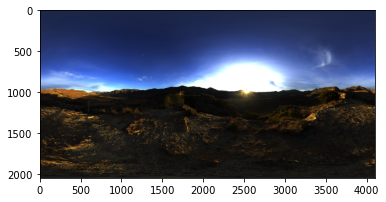

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(2048, 4096, 3) 1.17214391623891 0.0


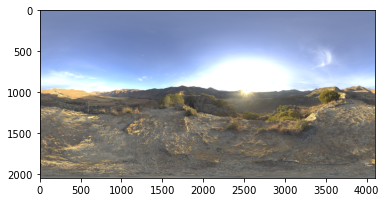

(3, 2, 3, 3)
(3, 9) [[ 0.22937769 -0.04451907  0.06260963 -0.02101421  0.06540306 -0.04997584
  -0.0786218  -0.03302749  0.01226678]
 [ 0.25632477 -0.03542881  0.10424671 -0.02318265  0.06128018 -0.04464541
  -0.08090921 -0.03008108  0.00506672]
 [ 0.3411083  -0.01365438  0.21269385 -0.01625202  0.04812097 -0.02866737
  -0.06995659 -0.01989797 -0.00369424]]
[[[[ 0.22937769  0.          0.        ]
   [ 0.06260963 -0.02101421  0.        ]
   [-0.0786218  -0.03302749  0.01226678]]

  [[ 0.          0.          0.        ]
   [ 0.         -0.04451907  0.        ]
   [ 0.         -0.04997584  0.06540306]]]


 [[[ 0.25632477  0.          0.        ]
   [ 0.10424671 -0.02318265  0.        ]
   [-0.08090921 -0.03008108  0.00506672]]

  [[ 0.          0.          0.        ]
   [ 0.         -0.03542881  0.        ]
   [ 0.         -0.04464541  0.06128018]]]


 [[[ 0.3411083   0.          0.        ]
   [ 0.21269385 -0.01625202  0.        ]
   [-0.06995659 -0.01989797 -0.00369424]]

  [[ 0.    

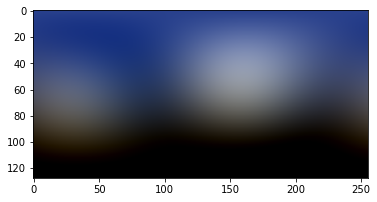

(3, 2, 3, 3)
(3, 9) [[ 0.56857099 -0.03619881  0.08049857 -0.00511678  0.05523422 -0.04991292
  -0.06691921 -0.02721628  0.0098657 ]
 [ 0.5906201  -0.02451691  0.12855178 -0.006398    0.05037777 -0.04197581
  -0.06070255 -0.0239834   0.00416554]
 [ 0.64125207 -0.00330133  0.23144282 -0.00368681  0.03875584 -0.02772303
  -0.0333012  -0.01572261 -0.00221113]]
[[[[ 0.56857099  0.          0.        ]
   [ 0.08049857 -0.00511678  0.        ]
   [-0.06691921 -0.02721628  0.0098657 ]]

  [[ 0.          0.          0.        ]
   [ 0.         -0.03619881  0.        ]
   [ 0.         -0.04991292  0.05523422]]]


 [[[ 0.5906201   0.          0.        ]
   [ 0.12855178 -0.006398    0.        ]
   [-0.06070255 -0.0239834   0.00416554]]

  [[ 0.          0.          0.        ]
   [ 0.         -0.02451691  0.        ]
   [ 0.         -0.04197581  0.05037777]]]


 [[[ 0.64125207  0.          0.        ]
   [ 0.23144282 -0.00368681  0.        ]
   [-0.0333012  -0.01572261 -0.00221113]]

  [[ 0.    

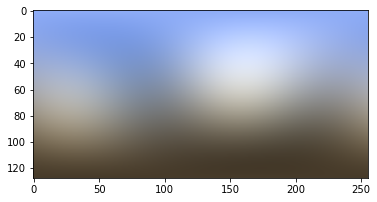

In [4]:
import skimage
import pyshtools as pysh
import numpy as np
import matplotlib.pyplot as plt
from envmap import EnvironmentMap, rotation_matrix
import numpy as np
from tools3d import spharm

class TonemapHDR(object):
    """
        Tonemap HDR image globally. First, we find alpha that maps the (max(numpy_img) * percentile) to max_mapping.
        Then, we calculate I_out = alpha * I_in ^ (1/gamma)
        input : nd.array batch of images : [H, W, C]
        output : nd.array batch of images : [H, W, C]
    """

    def __init__(self, gamma=2.4, percentile=50, max_mapping=0.5):
        self.gamma = gamma
        self.percentile = percentile
        self.max_mapping = max_mapping  # the value to which alpha will map the (max(numpy_img) * percentile) to

    def __call__(self, numpy_img, clip=True, alpha=None, gamma=True):
        if gamma:
            power_numpy_img = np.power(numpy_img, (1 / (self.gamma + 1e-10)))
        else:
            power_numpy_img = numpy_img
        non_zero = power_numpy_img > 0
        if non_zero.any():
            r_percentile = np.percentile(power_numpy_img[non_zero], self.percentile)
        else:
            r_percentile = np.percentile(power_numpy_img, self.percentile)
        if alpha is None:
            alpha = self.max_mapping / (r_percentile + 1e-10)
        tonemapped_img = np.multiply(alpha, power_numpy_img)

        if clip:
            tonemapped_img_clip = np.clip(tonemapped_img, 0, 1)

        return tonemapped_img_clip.astype('float32'), alpha, tonemapped_img

def get_shcoeff(image, Lmax=100):
    """
    @param image: image in HWC @param 1max: maximum of sh
    """
    output_coeff = []
    for c_id in range(image.shape[-1]):
        # Create a SHGrid object from the image
        grid = pysh.SHGrid.from_array(image[:,:,c_id], grid='GLQ')
        # Compute the spherical harmonic coefficients
        coeffs = grid.expand(normalization='4pi', csphase=1, lmax_calc=Lmax)
        coeffs = coeffs.to_array()
        output_coeff.append(coeffs[None])
    
    output_coeff = np.concatenate(output_coeff,axis=0)
    return output_coeff

import pyshtools as pysh
def flatten_sh_coeff(sh_coeff, max_sh_level=2):
    """
    flatten spherical harmonics coefficient to 3xC matrix
    """
    flatted_coeff = np.zeros((3, (max_sh_level+1) ** 2))
    # we will put into array in the format of 
    # [0_0, 1_-1, 1_0, 1_1, 2_-2, 2_-1, 2_0, 2_1, 2_2]
    # where first number is the order and the second number is the position in order
    for i in range(3):
        c = 0
        for j in range(max_sh_level+1):
            for k in range(j, 0, -1):
                flatted_coeff[i, c] = sh_coeff[i, 1, j, k]
                c +=1
            for k in range(j+1):
                flatted_coeff[i, c] = sh_coeff[i, 0, j, k]
                c += 1
    return flatted_coeff

def unfold_sh_coeff(flatted_coeff, max_sh_level=2):
    """
    flatten spherical harmonics coefficient to 3xC matrix
    #  array format [0_0, 1_-1, 1_0, 1_1, 2_-2, 2_-1, 2_0, 2_1, 2_2]
    """
    sh_coeff = np.zeros((3, 2, max_sh_level+1, max_sh_level+1))
    for i in range(3):
        c = 0
        for j in range(max_sh_level+1):
            for k in range(j, 0, -1):
                sh_coeff[i, 1, j, k] = flatted_coeff[i, c]
                c +=1
            for k in range(j+1):
                sh_coeff[i, 0, j, k] = flatted_coeff[i, c]
                c += 1
    return sh_coeff

def compute_background(
        hfov, sh, lmax=6,
        image_width=512, show_entire_env_map=True
    ):
    # Generate random spherical harmonic coefficients
    loaded_coeff = sh
    # require_unfold = (lmax == 2)

    # if require_unfold:
    #     loaded_coeff = unfold_sh_coeff(loaded_coeff) #shape [3,9]
    loaded_coeff = unfold_sh_coeff(loaded_coeff, lmax)
    
    output_image = []
    for ch in (range(3)):
        coeffs = loaded_coeff[ch]
            
        # Create SHCoeffs class object from the coefficients
        sh_coeffs = pysh.SHCoeffs.from_array(coeffs, lmax=lmax, normalization='4pi', csphase=1)

        # Create a grid of latitudes and longitudes
        if show_entire_env_map:
            theta = np.linspace(np.pi / 2, -np.pi / 2, image_width)
            phi = np.linspace(0, np.pi * 2, 2*image_width)
        else:
            theta = np.linspace(hfov, -hfov, image_width) #vertical
            phi = np.linspace(-hfov, hfov, image_width) #horizontal

        lat, lon = np.meshgrid(theta, phi, indexing='ij')

        # Evaluate the spherical harmonics on the grid
        grid_data = sh_coeffs.expand(grid="GLQ", lat=lat, lon=lon, lmax_calc=lmax, degrees=False)
        output_image.append(grid_data[...,None])    
    output_image = np.concatenate(output_image, axis=-1)
    output_image = np.clip(output_image, 0.0 ,1.0)
    return output_image

from envmap import EnvironmentMap, rotation_matrix
import os
os.environ["OPENCV_IO_ENABLE_OPENEXR"]="1"
import cv2
e = EnvironmentMap('/home/mint/Dev/DiFaReli/difareli-faster/eval_request/Sumit/difareli_test/kiara_2_sunrise_16k.exr0001.exr', 'latlong')
she = spharm.SphericalHarmonic(e, max_l=2)
print(she)

max_l = 2
print(e.data.shape, e.data.max(), e.data.min())
image = skimage.io.imread('/home/mint/Dev/DiFaReli/difareli-faster/eval_request/Sumit/difareli_test/kiara_2_sunrise_16k.exr0001.exr')
print(image.shape, image.max(), image.min())
image = skimage.img_as_float(image[0])
print(image.shape, image.max(), image.min())
# assert False
plt.imshow(image)
plt.show()
# Apply tonemapping
image_tm_clip, alpha, image_tm = TonemapHDR()(image)
print(image_tm.shape, image_tm.max(), image_tm.min())
plt.imshow(image_tm)
plt.show()
coeff = get_shcoeff(image, Lmax=max_l)
print(coeff.shape)
shcoeff = flatten_sh_coeff(coeff, max_sh_level=max_l)
print(shcoeff.shape, shcoeff)
print(unfold_sh_coeff(shcoeff, max_sh_level=max_l), unfold_sh_coeff(shcoeff, max_sh_level=max_l).shape)
background = compute_background(90, shcoeff, show_entire_env_map=True, lmax=max_l, image_width=128)
np.save('./pure.npy', shcoeff.transpose(1, 0))
plt.imshow(background)
plt.show()

coeff = get_shcoeff(image_tm, Lmax=max_l)
print(coeff.shape)
shcoeff = flatten_sh_coeff(coeff, max_sh_level=max_l)
print(shcoeff.shape, shcoeff)
print(unfold_sh_coeff(shcoeff, max_sh_level=max_l), unfold_sh_coeff(shcoeff, max_sh_level=max_l).shape)
background = compute_background(90, shcoeff, show_entire_env_map=True, lmax=max_l, image_width=128)
np.save('./pure_tm.npy', shcoeff.transpose(1, 0))
plt.imshow(background)
plt.show()

Stream #0: not enough frames to estimate rate; consider increasing probesize


(2048, 4096, 3) 255 0
(2048, 4096, 3) 1.0 0.0


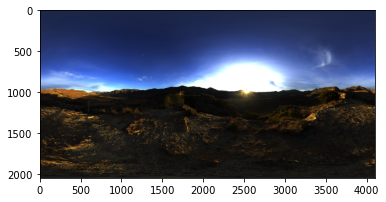

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(2048, 4096, 3) 1.17214391623891 0.0


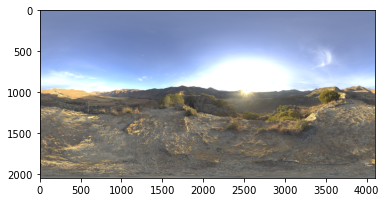

(3, 2, 3, 3)
SH USED:
(3, 9) [[ 0.22937769 -0.04451907  0.06260963 -0.02101421  0.06540306 -0.04997584
  -0.0786218  -0.03302749  0.01226678]
 [ 0.25632477 -0.03542881  0.10424671 -0.02318265  0.06128018 -0.04464541
  -0.08090921 -0.03008108  0.00506672]
 [ 0.3411083  -0.01365438  0.21269385 -0.01625202  0.04812097 -0.02866737
  -0.06995659 -0.01989797 -0.00369424]]
[[[[ 0.22937769  0.          0.        ]
   [ 0.06260963 -0.02101421  0.        ]
   [-0.0786218  -0.03302749  0.01226678]]

  [[ 0.          0.          0.        ]
   [ 0.         -0.04451907  0.        ]
   [ 0.         -0.04997584  0.06540306]]]


 [[[ 0.25632477  0.          0.        ]
   [ 0.10424671 -0.02318265  0.        ]
   [-0.08090921 -0.03008108  0.00506672]]

  [[ 0.          0.          0.        ]
   [ 0.         -0.03542881  0.        ]
   [ 0.         -0.04464541  0.06128018]]]


 [[[ 0.3411083   0.          0.        ]
   [ 0.21269385 -0.01625202  0.        ]
   [-0.06995659 -0.01989797 -0.00369424]]

  

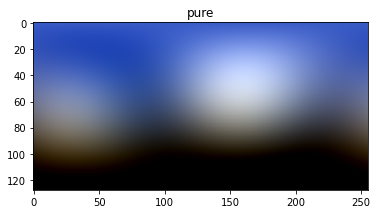

(256, 512, 3) 1.0 0.0


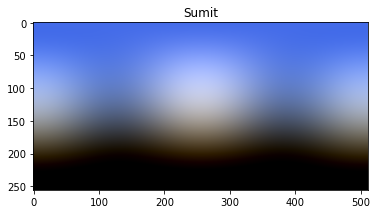

AssertionError: 

In [7]:
from envmap import EnvironmentMap, rotation_matrix
import os
os.environ["OPENCV_IO_ENABLE_OPENEXR"]="1"
import cv2
import skimage
import matplotlib.pyplot as plt
from scipy.special import sph_harm
def compute_background(
        hfov, sh, lmax=6,
        image_width=512, show_entire_env_map=True
    ):
    # Generate random spherical harmonic coefficients
    loaded_coeff = sh
    require_unfold = (lmax == 2)

    if require_unfold:
        loaded_coeff = unfold_sh_coeff(loaded_coeff) #shape [3,9]
    
    output_image = []
    for ch in (range(3)):
        coeffs = loaded_coeff[ch]
            
        # Create SHCoeffs class object from the coefficients
        sh_coeffs = pysh.SHCoeffs.from_array(coeffs, lmax=lmax, normalization='4pi', csphase=1)

        # Create a grid of latitudes and longitudes
        if show_entire_env_map:
            theta = np.linspace(np.pi / 2, -np.pi / 2, image_width)
            phi = np.linspace(0, np.pi * 2, 2*image_width)
        else:
            theta = np.linspace(hfov, -hfov, image_width) #vertical
            phi = np.linspace(-hfov, hfov, image_width) #horizontal

        lat, lon = np.meshgrid(theta, phi, indexing='ij')

        # Evaluate the spherical harmonics on the grid
        grid_data = sh_coeffs.expand(grid="GLQ", lat=lat, lon=lon, lmax_calc=lmax, degrees=False)
        output_image.append(grid_data[...,None])    
    output_image = np.concatenate(output_image,axis=-1)
    # output_image = np.clip(output_image, 0.0 ,1.0)
    output_image = np.clip(output_image, 0.0 ,None)
    output_image /= output_image.max()
    return output_image

def render_sh(coeffs, res=256):
    """Render an environment map from SH coefficients."""
    y, x = np.indices((res, 2 * res))
    theta = np.pi * y / res  # Theta from 0 to pi
    phi = 2 * np.pi * x / (2 * res)  # Phi from 0 to 2*pi

    sh_order = 2  # SH order for 9 coefficients
    sh_basis = np.array([
        sph_harm(m, l, phi, theta).real for l in range(sh_order + 1) for m in range(-l, l + 1)
    ])  # Shape: (9, res, res)

    # Reconstruct environment map for each RGB channel
    env_map = np.zeros((res, 2 * res, 3))
    for c in range(3):  # RGB channels
        for i, basis in enumerate(sh_basis):
            env_map[:, :, c] += coeffs[c, i] * basis

    # Clip and normalize for visualization
    env_map = np.clip(env_map, 0, None)  # Ensure no negative values
    env_map /= env_map.max()  # Normalize to [0, 1] for visualization

    return env_map
file = '/home/mint/Dev/DiFaReli/difareli-faster/eval_request/Sumit/difareli_test/kiara_2_sunrise_16k.exr0001.exr'
# file = './goegap_road_4k.hdr'
# e = EnvironmentMap(file, 'latlong')
max_l = 2
# print(e.data.shape, e.data.max(), e.data.min())
image = skimage.io.imread(file)[0]
print(image.shape, image.max(), image.min())
image = skimage.img_as_float(image)
print(image.shape, image.max(), image.min())
# assert False
plt.imshow(image)
plt.show()
# Apply tonemapping
image_tm_clip, alpha, image_tm = TonemapHDR()(image)
print(image_tm.shape, image_tm.max(), image_tm.min())
plt.imshow(image_tm)
plt.show()
coeff = get_shcoeff(image, Lmax=max_l)
print(coeff.shape)
shcoeff = flatten_sh_coeff(coeff, max_sh_level=max_l)
print("SH USED:")
print(shcoeff.shape, shcoeff)
print(unfold_sh_coeff(shcoeff, max_sh_level=max_l), unfold_sh_coeff(shcoeff, max_sh_level=max_l).shape)
background = compute_background(90, shcoeff, show_entire_env_map=True, lmax=max_l, image_width=128)
print(background.shape, background.max(), background.min())
np.save('./pure.npy', shcoeff.transpose(1, 0))
plt.imshow(background)
plt.title('pure')
plt.show()
sumit = render_sh(shcoeff.transpose(0, 1), res=256)
print(sumit.shape, sumit.max(), sumit.min())
plt.imshow(sumit)
plt.title('Sumit')
plt.show()
assert False

coeff = get_shcoeff(image_tm, Lmax=max_l)
print(coeff.shape)
shcoeff = flatten_sh_coeff(coeff, max_sh_level=max_l)
print(shcoeff.shape, shcoeff)
print(unfold_sh_coeff(shcoeff, max_sh_level=max_l), unfold_sh_coeff(shcoeff, max_sh_level=max_l).shape)
background = compute_background(90, shcoeff, show_entire_env_map=True, lmax=max_l, image_width=128)
np.save('./pure_tm.npy', shcoeff.transpose(1, 0))
plt.imshow(background)
plt.show()

In [58]:
file = '/home/mint/Dev/DiFaReli/difareli-faster/eval_request/Sumit/difareli_test/kiara_2_sunrise_16k.exr0001.exr'
e_cv = EnvironmentMap(cv2.imread(file, -1), 'latlong')
print(e_cv.data.shape, e_cv.data.max(), e_cv.data.min())
e = EnvironmentMap(file, 'latlong')
print(e.data.shape, e.data.max(), e.data.min())
print(np.mean(e_cv.data), np.mean(e.data))
assert np.allclose(e_cv.data.astype(np.float16), e.data.astype(np.float16))
e = EnvironmentMap(skimage.io.imread(file), 'latlong')
print(e.data.shape, e.data.max(), e.data.min())
image = skimage.img_as_float(image)
image_tm_clip, alpha, image_tm = TonemapHDR()(image)
print(image.shape, image.max(), image.min())
print(image_tm.shape, image_tm.max(), image_tm.min())
print(image_tm_clip.shape, image_tm_clip.max(), image_tm_clip.min())
plt.imshow(image)
plt.show()
plt.imshow(image_tm_clip)
plt.show()

plt.imshow(image_tm)
plt.show()

(2048, 4096, 4) 405504.0 0.0
(2048, 4096, 4) 405504.0 0.0
0.9290555786062669 0.9290554


AssertionError: 

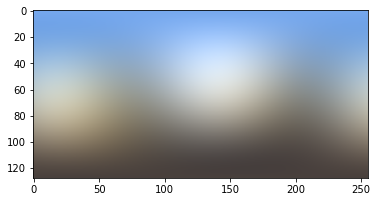

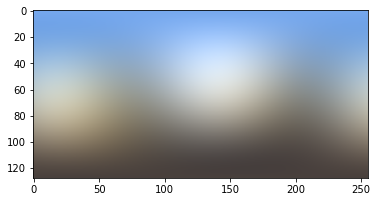

In [45]:
background = compute_background(90, shcoeff, show_entire_env_map=True, lmax=max_l, image_width=128)
plt.imshow(background)
plt.show()

background = compute_background(0, shcoeff, show_entire_env_map=True, lmax=max_l, image_width=128)
plt.imshow(background)
plt.show()

# Test combined SH from shpram

(2048, 4096, 4) 405504.0 0.0
(2048, 4096, 4) 207.60469 0.0
(2048, 4096, 4) 1.0 0.0


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


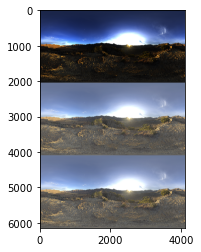

In [33]:
import skimage
import pyshtools as pysh
import numpy as np
import matplotlib.pyplot as plt
from envmap import EnvironmentMap, rotation_matrix
import numpy as np
from tools3d import spharm

class TonemapHDR(object):
    """
        Tonemap HDR image globally. First, we find alpha that maps the (max(numpy_img) * percentile) to max_mapping.
        Then, we calculate I_out = alpha * I_in ^ (1/gamma)
        input : nd.array batch of images : [H, W, C]
        output : nd.array batch of images : [H, W, C]
    """

    def __init__(self, gamma=2.4, percentile=50, max_mapping=0.5):
        self.gamma = gamma
        self.percentile = percentile
        self.max_mapping = max_mapping  # the value to which alpha will map the (max(numpy_img) * percentile) to

    def __call__(self, numpy_img, clip=True, alpha=None, gamma=True):
        if gamma:
            power_numpy_img = np.power(numpy_img, (1 / (self.gamma + 1e-10)))
        else:
            power_numpy_img = numpy_img
        non_zero = power_numpy_img > 0
        if non_zero.any():
            r_percentile = np.percentile(power_numpy_img[non_zero], self.percentile)
        else:
            r_percentile = np.percentile(power_numpy_img, self.percentile)
        if alpha is None:
            alpha = self.max_mapping / (r_percentile + 1e-10)
        tonemapped_img = np.multiply(alpha, power_numpy_img)

        if clip:
            tonemapped_img_clip = np.clip(tonemapped_img, 0, 1)

        return tonemapped_img_clip.astype('float32'), alpha, tonemapped_img

def get_shcoeff(image, Lmax=100):
    """
    @param image: image in HWC @param 1max: maximum of sh
    """
    output_coeff = []
    for c_id in range(image.shape[-1]):
        # Create a SHGrid object from the image
        grid = pysh.SHGrid.from_array(image[:,:,c_id], grid='GLQ')
        # Compute the spherical harmonic coefficients
        coeffs = grid.expand(normalization='4pi', csphase=1, lmax_calc=Lmax)
        coeffs = coeffs.to_array()
        output_coeff.append(coeffs[None])
    
    output_coeff = np.concatenate(output_coeff,axis=0)
    return output_coeff

import pyshtools as pysh
def flatten_sh_coeff(sh_coeff, max_sh_level=2):
    """
    flatten spherical harmonics coefficient to 3xC matrix
    """
    flatted_coeff = np.zeros((3, (max_sh_level+1) ** 2))
    # we will put into array in the format of 
    # [0_0, 1_-1, 1_0, 1_1, 2_-2, 2_-1, 2_0, 2_1, 2_2]
    # where first number is the order and the second number is the position in order
    for i in range(3):
        c = 0
        for j in range(max_sh_level+1):
            for k in range(j, 0, -1):
                flatted_coeff[i, c] = sh_coeff[i, 1, j, k]
                c +=1
            for k in range(j+1):
                flatted_coeff[i, c] = sh_coeff[i, 0, j, k]
                c += 1
    return flatted_coeff

def unfold_sh_coeff(flatted_coeff, max_sh_level=2):
    """
    flatten spherical harmonics coefficient to 3xC matrix
    #  array format [0_0, 1_-1, 1_0, 1_1, 2_-2, 2_-1, 2_0, 2_1, 2_2]
    """
    sh_coeff = np.zeros((3, 2, max_sh_level+1, max_sh_level+1))
    for i in range(3):
        c = 0
        for j in range(max_sh_level+1):
            for k in range(j, 0, -1):
                sh_coeff[i, 1, j, k] = flatted_coeff[i, c]
                c +=1
            for k in range(j+1):
                sh_coeff[i, 0, j, k] = flatted_coeff[i, c]
                c += 1
    return sh_coeff

def compute_background(
        hfov, sh, lmax=6,
        image_width=512, show_entire_env_map=True
    ):
    # Generate random spherical harmonic coefficients
    loaded_coeff = sh
    # require_unfold = (lmax == 2)

    # if require_unfold:
    #     loaded_coeff = unfold_sh_coeff(loaded_coeff) #shape [3,9]
    loaded_coeff = unfold_sh_coeff(loaded_coeff, lmax)
    
    output_image = []
    for ch in (range(3)):
        coeffs = loaded_coeff[ch]
            
        # Create SHCoeffs class object from the coefficients
        sh_coeffs = pysh.SHCoeffs.from_array(coeffs, lmax=lmax, normalization='4pi', csphase=1)

        # Create a grid of latitudes and longitudes
        if show_entire_env_map:
            theta = np.linspace(np.pi / 2, -np.pi / 2, image_width)
            phi = np.linspace(0, np.pi * 2, 2*image_width)
        else:
            theta = np.linspace(hfov, -hfov, image_width) #vertical
            phi = np.linspace(-hfov, hfov, image_width) #horizontal

        lat, lon = np.meshgrid(theta, phi, indexing='ij')

        # Evaluate the spherical harmonics on the grid
        grid_data = sh_coeffs.expand(grid="GLQ", lat=lat, lon=lon, lmax_calc=lmax, degrees=False)
        output_image.append(grid_data[...,None])    
    output_image = np.concatenate(output_image, axis=-1)
    # output_image = np.clip(output_image, 0.0 ,1.0)
    return output_image

from envmap import EnvironmentMap, rotation_matrix
import os
os.environ["OPENCV_IO_ENABLE_OPENEXR"]="1"
import cv2
from PIL import Image

max_l = 2
e = EnvironmentMap('/home/mint/Dev/DiFaReli/difareli-faster/eval_request/Sumit/difareli_test/kiara_2_sunrise_16k.exr0001.exr', 'latlong')
print(e.data.shape, e.data.max(), e.data.min())
image = e.data
image_tm_clip, alpha, image_tm = TonemapHDR()(image)
print(image_tm.shape, image_tm.max(), image_tm.min())
print(image_tm_clip.shape, image_tm_clip.max(), image_tm_clip.min())
plt.imshow(np.concatenate((image, image_tm, image_tm_clip), axis=0))
plt.show()
Image.fromarray((image_tm_clip * 255).astype(np.uint8)).resize((2048, 1024)).save('image_tm.png')
